In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [ ]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000167941""","""heel_bone_mineral_density_bmd_…",0.004143,0.309961,0.309961,1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
…,…,…,…,…,…
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0
"""ENSG00000114796""","""position_of_pulse_wave_notch_i…",0.03963,-0.003476,0.003476,-1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1


In [4]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Choose Gene Body
        ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # (pl.col('relative_cds_position')>=0.5) &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region']).union(set(existing_annos))
    )
)

anno.head().collect()

Error: path "/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


promoterai,loftee_lc,encode_dels,consequence_stop_lost,consequence_frameshift_variant,five_prime_utr_variant_consequence_uaug_lost,gpn_score,abexp_abs_max,region,cadd_raw,am_pathogenicity,verphylop,low_complexity_domain,absplice2_max,consequence_start_lost,five_prime_utr_variant_consequence_ustop_lost,five_prime_utr_variant_consequence_uaug_gained,encode_tf,mobi_curated_disorder_priority,consequence_missense_variant,relative_cds_position,consequence_stop_gained,consequence_splice_acceptor_variant,pangolin_score,encode_pls,score_pai3d,ted_domain,loftee_hc,consequence_synonymous_variant,five_prime_utr_variant_consequence_ustop_gained,id,delta_score,encode_pels,esmscoremissense,mobi_lip_full,consequence_splice_donor_variant
f32,i8,bool,i8,i8,u8,f32,f32,str,f32,f32,f32,bool,f32,i8,u8,u8,bool,bool,i8,f32,i8,i8,f32,bool,f32,bool,i8,i8,u8,str,f32,bool,f32,bool,i8
0.0,0,false,0,0,0,-6.13,0.145382,"""ENSG00000104112""",5.221107,0.6793,10.541,false,0.002202,0,0,0,false,false,1,0.38,0,0,0.01,false,0.835758,true,0,0,0,"""chr15:51688397:G:A""",0.0,false,-6.18,true,0
0.0,0,false,0,0,0,-8.47,0.067689,"""ENSG00000116127""",4.401463,0.3752,4.069,false,0.009521,0,0,0,false,false,1,0.6,0,0,0.0,false,0.0,false,0,0,0,"""chr2:73455162:C:G""",0.0,false,-4.235,false,0
0.0,0,false,0,0,0,-8.78,0.085274,"""ENSG00000137076""",3.622959,0.1793,7.063,false,0.002284,0,0,0,false,false,1,0.52,0,0,0.08,false,0.749405,true,0,0,0,"""chr9:35711346:T:A""",0.14,false,-1.937,true,0
0.0,0,false,0,0,0,-5.86,0.110739,"""ENSG00000250722""",4.110966,0.0,4.639,false,0.000481,0,0,0,false,false,1,0.12,0,0,0.0,false,0.0,false,0,0,0,"""chr5:42808215:C:T""",0.0,true,-5.376,false,0
0.0,0,false,0,0,0,-0.09,0.0,"""ENSG00000167791""",0.508567,0.0648,-0.082,false,0.000033,0,0,0,false,false,1,0.19,0,0,0.0,false,0.288076,false,0,0,0,"""chr11:67522634:G:A""",0.0,true,-4.004,false,0


In [5]:
# Add Olink measurements

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet

olink_appv = (
    pl.scan_parquet("/home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet")
    
    .rename({
        'mean_pheno_value': 'olink_mean_pheno',
    })
    .with_columns(
        olink_mean_pheno_abs = pl.col('olink_mean_pheno').abs(),
        region = pl.col('phenotype').str.replace(r'_olink', '')
    )
    
    .filter(
        pl.col('region').is_in(gene_trait_df.select('region').unique().to_series())
    )
    
    .select(['id', 'region', 'olink_mean_pheno', 'olink_mean_pheno_abs'])
)

anno = (
    anno.lazy()
    .join(
        olink_appv,
        on=['id', 'region'],
        how='inner'       # only keep variants with Olink measurements
    )
    .collect(engine='streaming')
)

anno

Error: path "/home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_ap
pv_percentiles.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_66968/3013719446.py:30: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


promoterai,loftee_lc,encode_dels,consequence_stop_lost,consequence_frameshift_variant,five_prime_utr_variant_consequence_uaug_lost,gpn_score,abexp_abs_max,region,cadd_raw,am_pathogenicity,verphylop,low_complexity_domain,absplice2_max,consequence_start_lost,five_prime_utr_variant_consequence_ustop_lost,five_prime_utr_variant_consequence_uaug_gained,encode_tf,mobi_curated_disorder_priority,consequence_missense_variant,relative_cds_position,consequence_stop_gained,consequence_splice_acceptor_variant,pangolin_score,encode_pls,score_pai3d,ted_domain,loftee_hc,consequence_synonymous_variant,five_prime_utr_variant_consequence_ustop_gained,id,delta_score,encode_pels,esmscoremissense,mobi_lip_full,consequence_splice_donor_variant,olink_mean_pheno,olink_mean_pheno_abs
f32,i8,bool,i8,i8,u8,f32,f32,str,f32,f32,f32,bool,f32,i8,u8,u8,bool,bool,i8,f32,i8,i8,f32,bool,f32,bool,i8,i8,u8,str,f32,bool,f32,bool,i8,f32,f32
0.0,0,false,0,0,0,-4.73,0.104483,"""ENSG00000155657""",3.205079,0.0,3.245,true,0.001688,0,0,0,false,true,1,0.31,0,0,0.06,false,0.0,false,0,0,0,"""chr2:178681669:G:T""",0.02,false,-6.773,true,0,-0.173018,0.173018
0.0074,0,false,0,0,0,-0.14,0.063033,"""ENSG00000155657""",1.674416,0.0,0.176,false,0.000263,0,0,0,false,false,1,0.37,0,0,0.0,false,0.0,false,0,0,0,"""chr2:178651517:C:A""",0.0,false,-8.22,false,0,-0.584763,0.584763
0.0,0,false,0,0,0,-2.8,0.091145,"""ENSG00000155657""",2.79206,0.0,1.976,false,0.001491,0,0,0,false,false,1,0.37,0,0,0.05,false,0.0,false,0,0,0,"""chr2:178649565:G:T""",0.0,false,-10.124,false,0,-0.449014,0.449014
0.0026,0,false,0,0,0,-3.29,0.062287,"""ENSG00000155657""",1.993858,0.0,0.195,false,0.000263,0,0,0,false,false,1,0.37,0,0,0.0,false,0.0,false,0,0,0,"""chr2:178651485:A:G""",0.0,false,-3.348,false,0,0.068953,0.068953
0.0,0,false,0,0,0,-2.12,0.064158,"""ENSG00000155657""",2.346146,0.0,-0.138,false,0.001581,0,0,0,false,true,1,0.31,0,0,0.11,false,0.0,false,0,0,0,"""chr2:178681088:C:T""",0.04,false,-4.025,true,0,1.005187,1.005187
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.0166,0,false,0,0,0,-5.76,0.028747,"""ENSG00000205758""",3.736476,0.2379,5.662,false,0.002258,0,0,0,false,false,1,0.71,0,0,0.01,false,0.602461,true,0,0,0,"""chr21:33597329:G:A""",0.0,false,-8.362,false,0,-3.056163,3.056163
0.0,0,true,0,0,0,-8.16,0.058024,"""ENSG00000164199""",3.401282,0.2153,6.462,false,0.0,0,0,0,false,false,1,0.97,0,0,0.0,false,0.0,false,0,0,0,"""chr5:91072557:A:C""",0.0,false,-4.194,false,0,-0.078201,0.078201
0.0,0,true,0,0,0,1.0,0.020933,"""ENSG00000110934""",0.492677,0.0642,-0.508,false,0.000034,0,0,0,false,false,1,0.68,0,0,0.02,false,0.0,false,0,0,0,"""chr12:51291956:C:G""",0.01,false,-2.636,true,0,1.642302,1.642302


In [6]:
exp_annos = pl.DataFrame({
    "category": ["olink", "olink"],
    "annotation": ["olink_mean_pheno", "olink_mean_pheno_abs"],
    "color": ["gray", "gray"],
    "label": ["Plasma Olink", "Plasma Olink (abs)"],
    "annotation_dir": [-1, 1],
}).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

anno_config_df = pl.concat([anno_config_df, exp_annos], how='vertical')
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1
"""naive""","""relative_cds_position""","""#b5de2b""","""Relative CDS Position""",-1


In [7]:
# # Load fillna annotations
# anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
# fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

# anno_fillna_melted = (
#     anno_fillna
#     .select(['id', 'region'] + list(fillna_cols))
#     .join(
#         anno.select(['id', 'region']).lazy(), 
#         on=['id', 'region'], 
#         how='semi'
#     )
#     .unpivot(
#         index=["id", "region"],
#         on=list(fillna_cols),
#         variable_name="annotation",
#         value_name="annotation_is_na"
#     )
#     .filter(
#         pl.col('annotation_is_na') == False
#     )
#     .with_columns(
#         annotation = pl.col('annotation').str.replace('_is_na$', '')
#     )
#     # .collect(engine='streaming')
# )


# selected_categories = ['olink', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # CDS
selected_categories = ['olink', 'missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains


selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].unique().to_list()

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    # Join Olink measurements
    .join(
        olink_appv,
        on=['id', 'region'],
        how='inner'       # only keep variants with Olink measurements
    )
    
    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_66968/1176793622.py:71: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score
str,str,str,f32
"""chr2:178759148:T:C""","""ENSG00000155657""","""am_pathogenicity""",0.0843
"""chr4:88052096:G:C""","""ENSG00000118762""","""am_pathogenicity""",0.6494
"""chr4:88046856:G:A""","""ENSG00000118762""","""am_pathogenicity""",0.0739
"""chr2:178759148:T:C""","""ENSG00000155657""","""cadd_raw""",2.509873
"""chr4:88052096:G:C""","""ENSG00000118762""","""cadd_raw""",4.511298
…,…,…,…
"""chr12:51291956:C:G""","""ENSG00000110934""","""olink_mean_pheno""",1.642302
"""chr12:51291895:C:G""","""ENSG00000110934""","""olink_mean_pheno""",-0.18396
"""chr1:62601876:A:G""","""ENSG00000132855""","""olink_mean_pheno_abs""",0.562463


In [8]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [9]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")

    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_na' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df["region", "phenotype"].lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("max")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    # D. Apply the group_by and aggregation lazily
    # .group_by(["region", "gene_name", "phenotype", "annotation"])
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None) # None maps to NaN for float columns
    )

    .filter(pl.col('annotation')!='loftee_hc')
    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    
    .drop_nans().drop_nulls()
    
    # --- 3. Execute the ENTIRE plan at once ---
    .collect(engine='streaming')
)

# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    final_lazy_plan
    
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (1029, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000213398""","""mean_sphered_cell_volume_int""","""olink_mean_pheno_abs""",52,0.234355,"""gray""","""Plasma Olink (abs)""",1,0.038548,0.106298,0.106298,1.0,0.234355,2.20469
"""ENSG00000169992""","""hand_grip_strength_left_int""","""cadd_raw""",74,-0.181192,"""#1f77b4""","""CADD Raw""",1,0.045692,-0.066102,0.066102,-1.0,0.181192,2.741119
"""ENSG00000117724""","""sitting_height_int""","""cadd_raw""",277,0.061898,"""#1f77b4""","""CADD Raw""",1,0.011398,-0.032492,0.032492,-1.0,-0.061898,-1.904984
"""ENSG00000111252""","""cholesterol_int""","""olink_mean_pheno""",132,0.102089,"""gray""","""Plasma Olink""",-1,0.015547,-0.168399,0.168399,-1.0,0.102089,0.606232
"""ENSG00000092853""","""mean_corpuscular_volume_int""","""esmscoremissense""",111,-0.016745,"""#feb72d""","""ESM1v""",-1,3.8169e-10,0.161941,0.161941,1.0,0.016745,0.103403
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000155506""","""red_blood_cell_erythrocyte_dis…","""olink_mean_pheno""",109,0.016393,"""gray""","""Plasma Olink""",-1,0.002595,0.189466,0.189466,1.0,-0.016393,-0.086524
"""ENSG00000154654""","""leg_fat_percentage_right_int""","""esmscoremissense""",69,0.260322,"""#feb72d""","""ESM1v""",-1,0.040021,0.159285,0.159285,1.0,-0.260322,-1.634312
"""ENSG00000117724""","""sitting_height_int""","""esmscoremissense""",277,0.045139,"""#feb72d""","""ESM1v""",-1,0.011398,-0.032492,0.032492,-1.0,0.045139,1.389215


In [10]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10) # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 50)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000213398""","""mean_sphered_cell_volume_int""","""olink_mean_pheno_abs""",52,0.234355,"""gray""","""Plasma Olink (abs)""",1,0.038548,0.106298,0.106298,1.0,0.234355,2.20469,8
"""ENSG00000117724""","""sitting_height_int""","""cadd_raw""",277,0.061898,"""#1f77b4""","""CADD Raw""",1,0.011398,-0.032492,0.032492,-1.0,-0.061898,-1.904984,8
"""ENSG00000111252""","""cholesterol_int""","""olink_mean_pheno""",132,0.102089,"""gray""","""Plasma Olink""",-1,0.015547,-0.168399,0.168399,-1.0,0.102089,0.606232,8
"""ENSG00000092853""","""mean_corpuscular_volume_int""","""esmscoremissense""",111,-0.016745,"""#feb72d""","""ESM1v""",-1,3.8169e-10,0.161941,0.161941,1.0,0.016745,0.103403,8
"""ENSG00000178607""","""total_protein_int""","""verphylop""",98,-0.252716,"""#942c80""","""Vertebrate PhyloP""",1,0.034842,-0.140309,0.140309,-1.0,0.252716,1.801141,8
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000119681""","""standing_height_int""","""olink_mean_pheno""",243,-0.008644,"""gray""","""Plasma Olink""",-1,2.2425e-7,0.109201,0.109201,1.0,0.008644,0.07916,8
"""ENSG00000130287""","""creactive_protein_int""","""verphylop""",145,0.045283,"""#942c80""","""Vertebrate PhyloP""",1,0.042962,0.077054,0.077054,1.0,0.045283,0.587682,8
"""ENSG00000130287""","""creactive_protein_int""","""gpn_score""",145,-0.068916,"""#942c80""","""GPN-MSA""",-1,0.042962,0.077054,0.077054,1.0,0.068916,0.894389,8


In [11]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


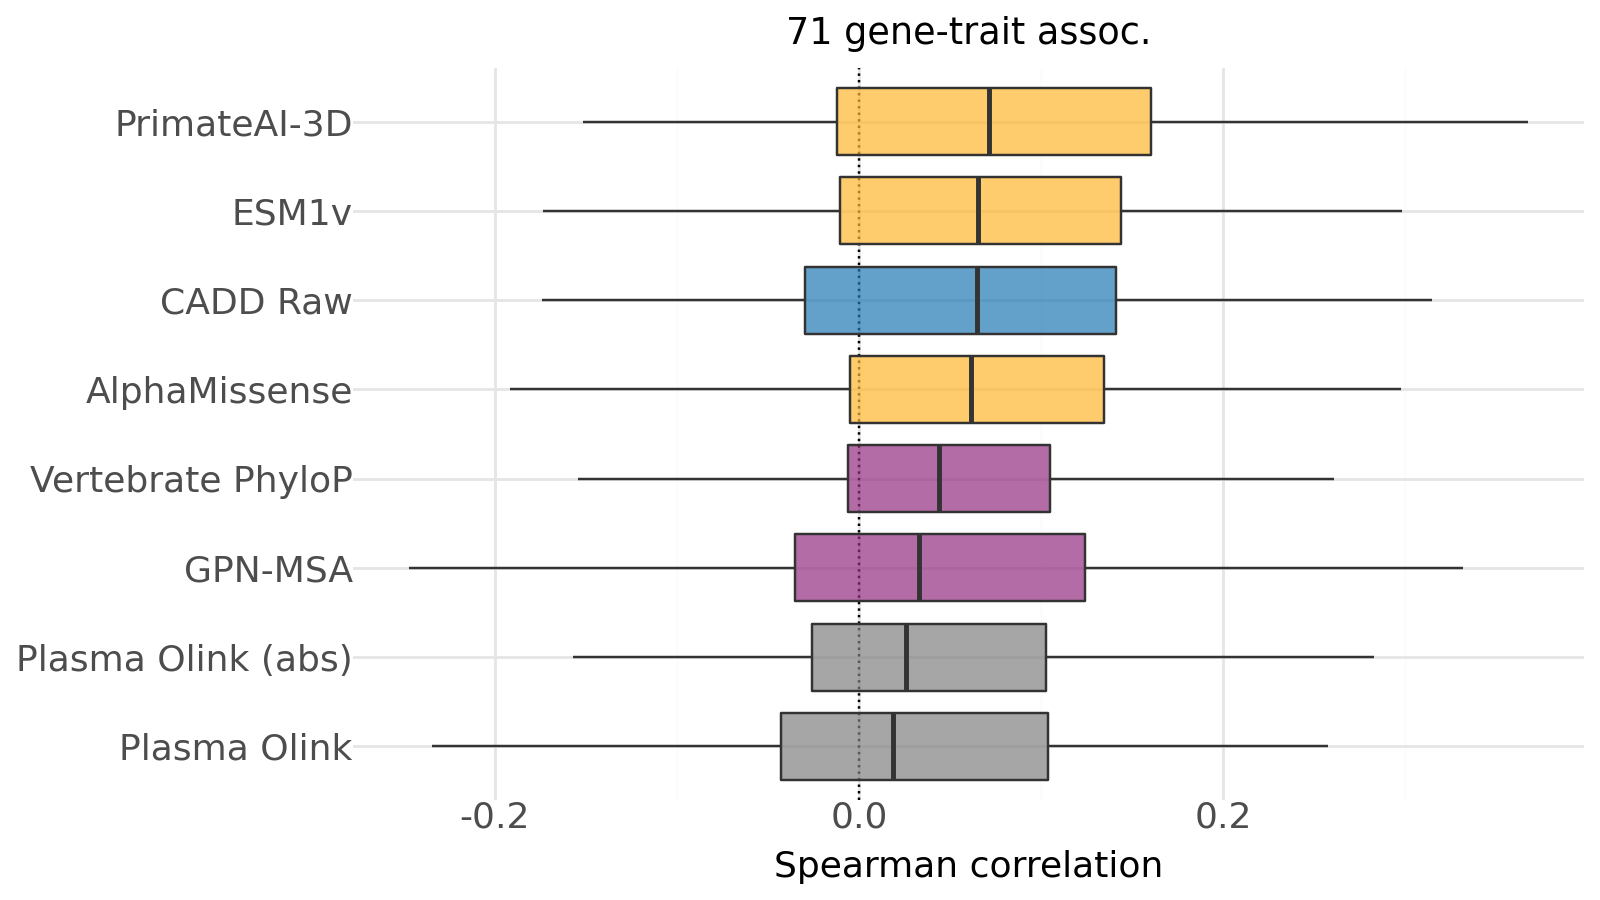

In [12]:
# Prepare for plotting
plotting_col = 'corr_beta'
# plotting_col = 'corr_beta_rescaled'

dashed_line_value = 1 if 'rescaled' in plotting_col else 0

med_df = filt_corr_df.drop_nans().group_by("annotation").agg(
    median_corr_beta = pl.col(plotting_col).median(),
)

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7)
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc."
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pd['annotation'].nunique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [13]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_66968/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""gpn_score""","""score_pai3d""",71,822.0,0.00898
"""gpn_score""","""am_pathogenicity""",71,894.0,0.027789
"""olink_mean_pheno""","""score_pai3d""",71,896.0,0.028612
"""olink_mean_pheno_abs""","""score_pai3d""",71,911.0,0.035479


## Find gene-trait pairs where olink_score_abs is the top annotation by corr_beta (ties included)

In [14]:
olink_top = (
    filt_corr_df
    .with_columns(
        max_corr = pl.col("corr_beta").max().over(["region", "phenotype"])
    )
    .filter(
        (pl.col("annotation") == "olink_mean_pheno_abs") &
        (pl.col("corr_beta") == pl.col("max_corr"))
    )
    .select(["region", "phenotype", "annotation", "corr_beta", "n_variants"])
    .sort(["corr_beta"], descending=True)
)

olink_top['phenotype'].value_counts(sort=True)

phenotype,count
str,u64
"""standing_height_int""",2
"""mean_corpuscular_haemoglobin_i…",2
"""total_bilirubin_int""",1
"""reticulocyte_percentage_int""",1
"""sitting_height_int""",1
…,…
"""forced_vital_capacity_fvc_best…",1
"""igf1_int""",1
"""creactive_protein_int""",1


In [20]:
gene_trait_df['phenotype'].to_list()

['mean_corpuscular_haemoglobin_int',
 'mean_corpuscular_haemoglobin_int',
 'cystatin_c_int',
 'heel_bone_mineral_density_bmd_tscore_automated_left_int',
 'standing_height_int',
 'aspartate_aminotransferase_int',
 'high_light_scatter_reticulocyte_count_int',
 'mean_corpuscular_haemoglobin_int',
 'albumin_int',
 'glycated_haemoglobin_hba1c_int',
 'alkaline_phosphatase_int',
 'seated_height_int',
 'apolipoprotein_a_int',
 'total_bilirubin_int',
 'aspartate_aminotransferase_int',
 'platelet_crit_int',
 'mean_platelet_thrombocyte_volume_int',
 'mean_platelet_thrombocyte_volume_int',
 'mean_sphered_cell_volume_int',
 'mean_corpuscular_haemoglobin_int',
 'reticulocyte_percentage_int',
 'townsend_deprivation_index_at_recruitment_int',
 'mean_corpuscular_haemoglobin_int',
 'ldl_direct_int',
 'hdl_cholesterol_int',
 'apolipoprotein_a_int',
 'platelet_distribution_width_int',
 'standing_height_int',
 'standing_height_int',
 'mean_platelet_thrombocyte_volume_int',
 'standing_height_int',
 'vitamin

In [21]:
phenotype_groups = ukb_phenotypes = {
    "Anthropometric": [
        "standing_height_int",
        "sitting_height_int",
        "seated_height_int",
        "weight_int",
        "body_mass_index_bmi_int",
        "waist_circumference_int",
        "hip_circumference_int",
        "body_fat_percentage_int",
        "whole_body_water_mass_int",
        "basal_metabolic_rate_int",
        "weight_impedance_int",
        "arm_fat_percentage_left_int",
        "arm_fat_percentage_right_int",
        "arm_fatfree_mass_left_int",
        "arm_fatfree_mass_right_int",
        "arm_predicted_mass_right_int",
        "leg_fat_percentage_left_int",
        "leg_fat_percentage_right_int",
        "leg_fat_mass_left_int",
        "leg_fat_mass_right_int",
        "leg_fatfree_mass_left_int",
        "leg_fatfree_mass_right_int",
        "leg_predicted_mass_left_int",
        "leg_predicted_mass_right_int",
        "trunk_fat_percentage_int",
        "trunk_fat_mass_int",
        "trunk_fatfree_mass_int",
        "trunk_predicted_mass_int",
        "heel_bone_mineral_density_bmd_left_int",
        "heel_bone_mineral_density_bmd_right_int",
        "heel_bone_mineral_density_bmd_tscore_automated_int",
        "heel_bone_mineral_density_bmd_tscore_automated_left_int",
        "heel_bone_mineral_density_bmd_tscore_automated_right_int",
        "forced_vital_capacity_fvc_int",
        "forced_vital_capacity_fvc_best_measure_int",
        "forced_expiratory_volume_in_1second_fev1_int",
        "forced_expiratory_volume_in_1second_fev1_best_measure_int",
        "forced_expiratory_volume_in_1second_fev1_predicted_int",
        "forced_expiratory_volume_in_1second_fev1_predicted_percentage_int",
        "peak_expiratory_flow_pef_int",
        "pulse_rate_int",
        "pulse_rate_automated_reading_int",
        "systolic_blood_pressure_automated_reading_int",
        "diastolic_blood_pressure_automated_reading_int",
        "stroke_volume_during_pwa_int",
        "position_of_pulse_wave_notch_int",
        "hand_grip_strength_left_int",
        "hand_grip_strength_right_int"
    ],
    "Blood Biochemistry": [
        "cholesterol_int",
        "hdl_cholesterol_int",
        "ldl_direct_int",
        "triglycerides_int",
        "apolipoprotein_a_int",
        "apolipoprotein_b_int",
        "lipoprotein_a_int",
        "albumin_int",
        "total_protein_int",
        "alkaline_phosphatase_int",
        "alanine_aminotransferase_int",
        "aspartate_aminotransferase_int",
        "gamma_glutamyltransferase_int",
        "total_bilirubin_int",
        "direct_bilirubin_int",
        "creatinine_int",
        "cystatin_c_int",
        "urea_int",
        "urate_int",
        "calcium_int",
        "phosphate_int",
        "glucose_int",
        "glycated_haemoglobin_hba1c_int",
        "igf1_int",
        "shbg_int",
        "testosterone_int",
        "vitamin_d_int",
        "creactive_protein_int"
    ],
    "Haematology": [
        "white_blood_cell_leukocyte_count_int",
        "red_blood_cell_erythrocyte_count_int",
        "haemoglobin_concentration_int",
        "haematocrit_percentage_int",
        "mean_corpuscular_volume_int",
        "mean_corpuscular_haemoglobin_int",
        "mean_corpuscular_haemoglobin_concentration_int",
        "red_blood_cell_erythrocyte_distribution_width_int",
        "platelet_count_int",
        "platelet_crit_int",
        "mean_platelet_thrombocyte_volume_int",
        "platelet_distribution_width_int",
        "neutrophill_count_int",
        "lymphocyte_count_int",
        "monocyte_count_int",
        "eosinophill_count_int",
        "basophill_count_int",
        "neutrophill_percentage_int",
        "lymphocyte_percentage_int",
        "monocyte_percentage_int",
        "eosinophill_percentage_int",
        "basophill_percentage_int",
        "reticulocyte_percentage_int",
        "reticulocyte_count_int",
        "mean_reticulocyte_volume_int",
        "mean_sphered_cell_volume_int",
        "immature_reticulocyte_fraction_int",
        "high_light_scatter_reticulocyte_percentage_int",
        "high_light_scatter_reticulocyte_count_int"
    ],
    "Urine Biochemistry": [
        "microalbumin_in_urine_int",
        "creatinine_enzymatic_in_urine_int"
    ],
    "Other": [
        "fluid_intelligence_score_int",
        "mean_time_to_correctly_identify_matches_int",
        "townsend_deprivation_index_at_recruitment_int",
        "age_at_hysterectomy_int",
        "fathers_age_at_death_int",
        "mothers_age_at_death_int",
        "age_started_wearing_glasses_or_contact_lenses_int"
    ]
}

# Reverse lookup helper (phenotype -> group)
pheno_to_group = {ph:grp for grp, phs in phenotype_groups.items() for ph in phs}


pheno_grouping_df = pl.DataFrame({
    'phenotype': [pheno for group in phenotype_groups for pheno in phenotype_groups[group]],
    'phenotype_group': [group for group in phenotype_groups for pheno in phenotype_groups[group]]
})

pheno_grouping_df

phenotype,phenotype_group
str,str
"""standing_height_int""","""Anthropometric"""
"""sitting_height_int""","""Anthropometric"""
"""seated_height_int""","""Anthropometric"""
"""weight_int""","""Anthropometric"""
"""body_mass_index_bmi_int""","""Anthropometric"""
…,…
"""townsend_deprivation_index_at_…","""Other"""
"""age_at_hysterectomy_int""","""Other"""
"""fathers_age_at_death_int""","""Other"""


In [22]:
plot_df = olink_top.join(pheno_grouping_df, on='phenotype', how='left')
plot_df = plot_df.to_pandas()

# 1. Get the desired order (sorted by count, descending)
category_order = plot_df['phenotype_group'].value_counts(sort=True, ascending=True).index

# 2. Create a new, ordered categorical column in the DataFrame
plot_df['phenotype_group_sorted'] = pd.Categorical(
    plot_df['phenotype_group'],
    categories=category_order,
    ordered=True
)


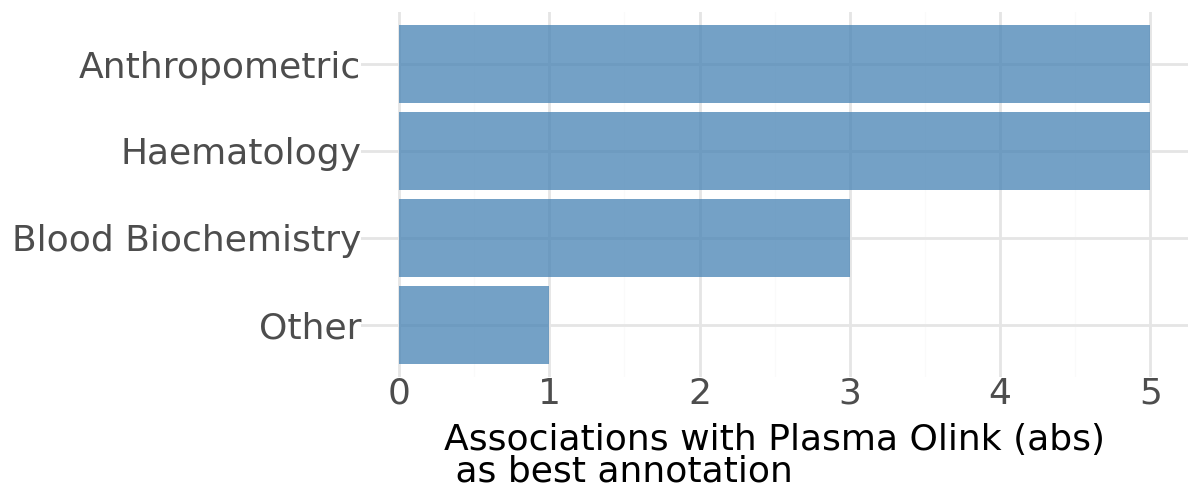

In [23]:
(
    ggplot(
        plot_df,
        aes(x='phenotype_group_sorted')
    )
    + geom_bar(stat='count', alpha=0.75, fill='steelblue')
    + theme_minimal()
    + labs(
        y="Associations with Plasma Olink (abs)\n as best annotation",
        x="",
    )
    + coord_flip()
    + theme(
        figure_size=(6, plot_df['phenotype_group_sorted'].nunique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)